Transformer 로 String 을 예측하는 문제를 해결하자
Depth 와 Organ type은 Special Token 으로 준비한다. d0, d1, d2, d4, o0, o1, o2, o4
SOS, PAD, EOS 도 마찬가지
파라미터는 KMeans로 클러스터링 해서 준비한다. 1d

In [7]:
import os
import numpy as np
from tqdm import tqdm
from string_to_xml_to_vec import xml2vec, pretty_print_xml, linked_to_recursive
import xml.etree.ElementTree as ET
token = []
if 0:
    dataset_dir = "../data/Sideview_Dec23_2024/xml"
    # List xml files
    xml_files = [f for f in os.listdir(dataset_dir) if f.endswith('.xml')]
else:
    dataset_dir = "temp"
    # List xml files
    #xml_files = [f for f in os.listdir(dataset_dir) if f.endswith('_est.xml')]
    xml_files = [f for f in os.listdir(dataset_dir) if f.endswith('_gt.xml')]
xml_files.sort()
plant_array = []
for xml_file in tqdm(xml_files):
    xml_file = os.path.join(dataset_dir, xml_file)
    tree = ET.parse(xml_file)
    root = tree.getroot()
    root = linked_to_recursive(root)
    for plant_instance in root:
        plant_instance_array = []
        xml2vec(plant_instance, plant_instance_array)
        plant_array.append(plant_instance_array)

100%|██████████| 212/212 [00:02<00:00, 96.79it/s] 


In [8]:
# Get the max depth and max len
max_depth = 0
max_len = 0
for plant_instance_array in plant_array:
    max_len = max(max_len, len(plant_instance_array))
    for plant in plant_instance_array:
        max_depth = max(max_depth, plant[0])

print("Max depth: ", max_depth)
print("n_depth: ", max_depth+1)
print("Max len: ", max_len)

Max depth:  3
n_depth:  4
Max len:  399


In [9]:
# from plant_tokenizer import unscale_vec, scale_vec
# The parameter will be quantized by organ types
all_shoot_params = []
all_internode_params = []
all_petiole_params = []
all_leaf_params = []
all_params_numbers = []
for token in plant_array:
    # plant_vectors = scale_vec(plant_vectors)
    for vec in token:
        depth = vec[0]
        organ_type = vec[1]
        if organ_type == 0:
            all_shoot_params.append(vec[2:])
        elif organ_type == 1:
            all_internode_params.append(vec[2:])
        elif organ_type == 2:
            all_petiole_params.append(vec[2:])
        elif organ_type == 3:
            all_leaf_params.append(vec[2:])
        all_params_numbers+= vec[2:]

all_shoot_params = np.array(all_shoot_params)
all_internode_params = np.array(all_internode_params)
all_petiole_params = np.array(all_petiole_params)
all_leaf_params = np.array(all_leaf_params)

print(all_shoot_params.shape)
print(all_internode_params.shape)
print(all_petiole_params.shape)
print(all_leaf_params.shape)
len(all_params_numbers)

(979, 5)
(6353, 4)
(6565, 5)
(6565, 4)


138520

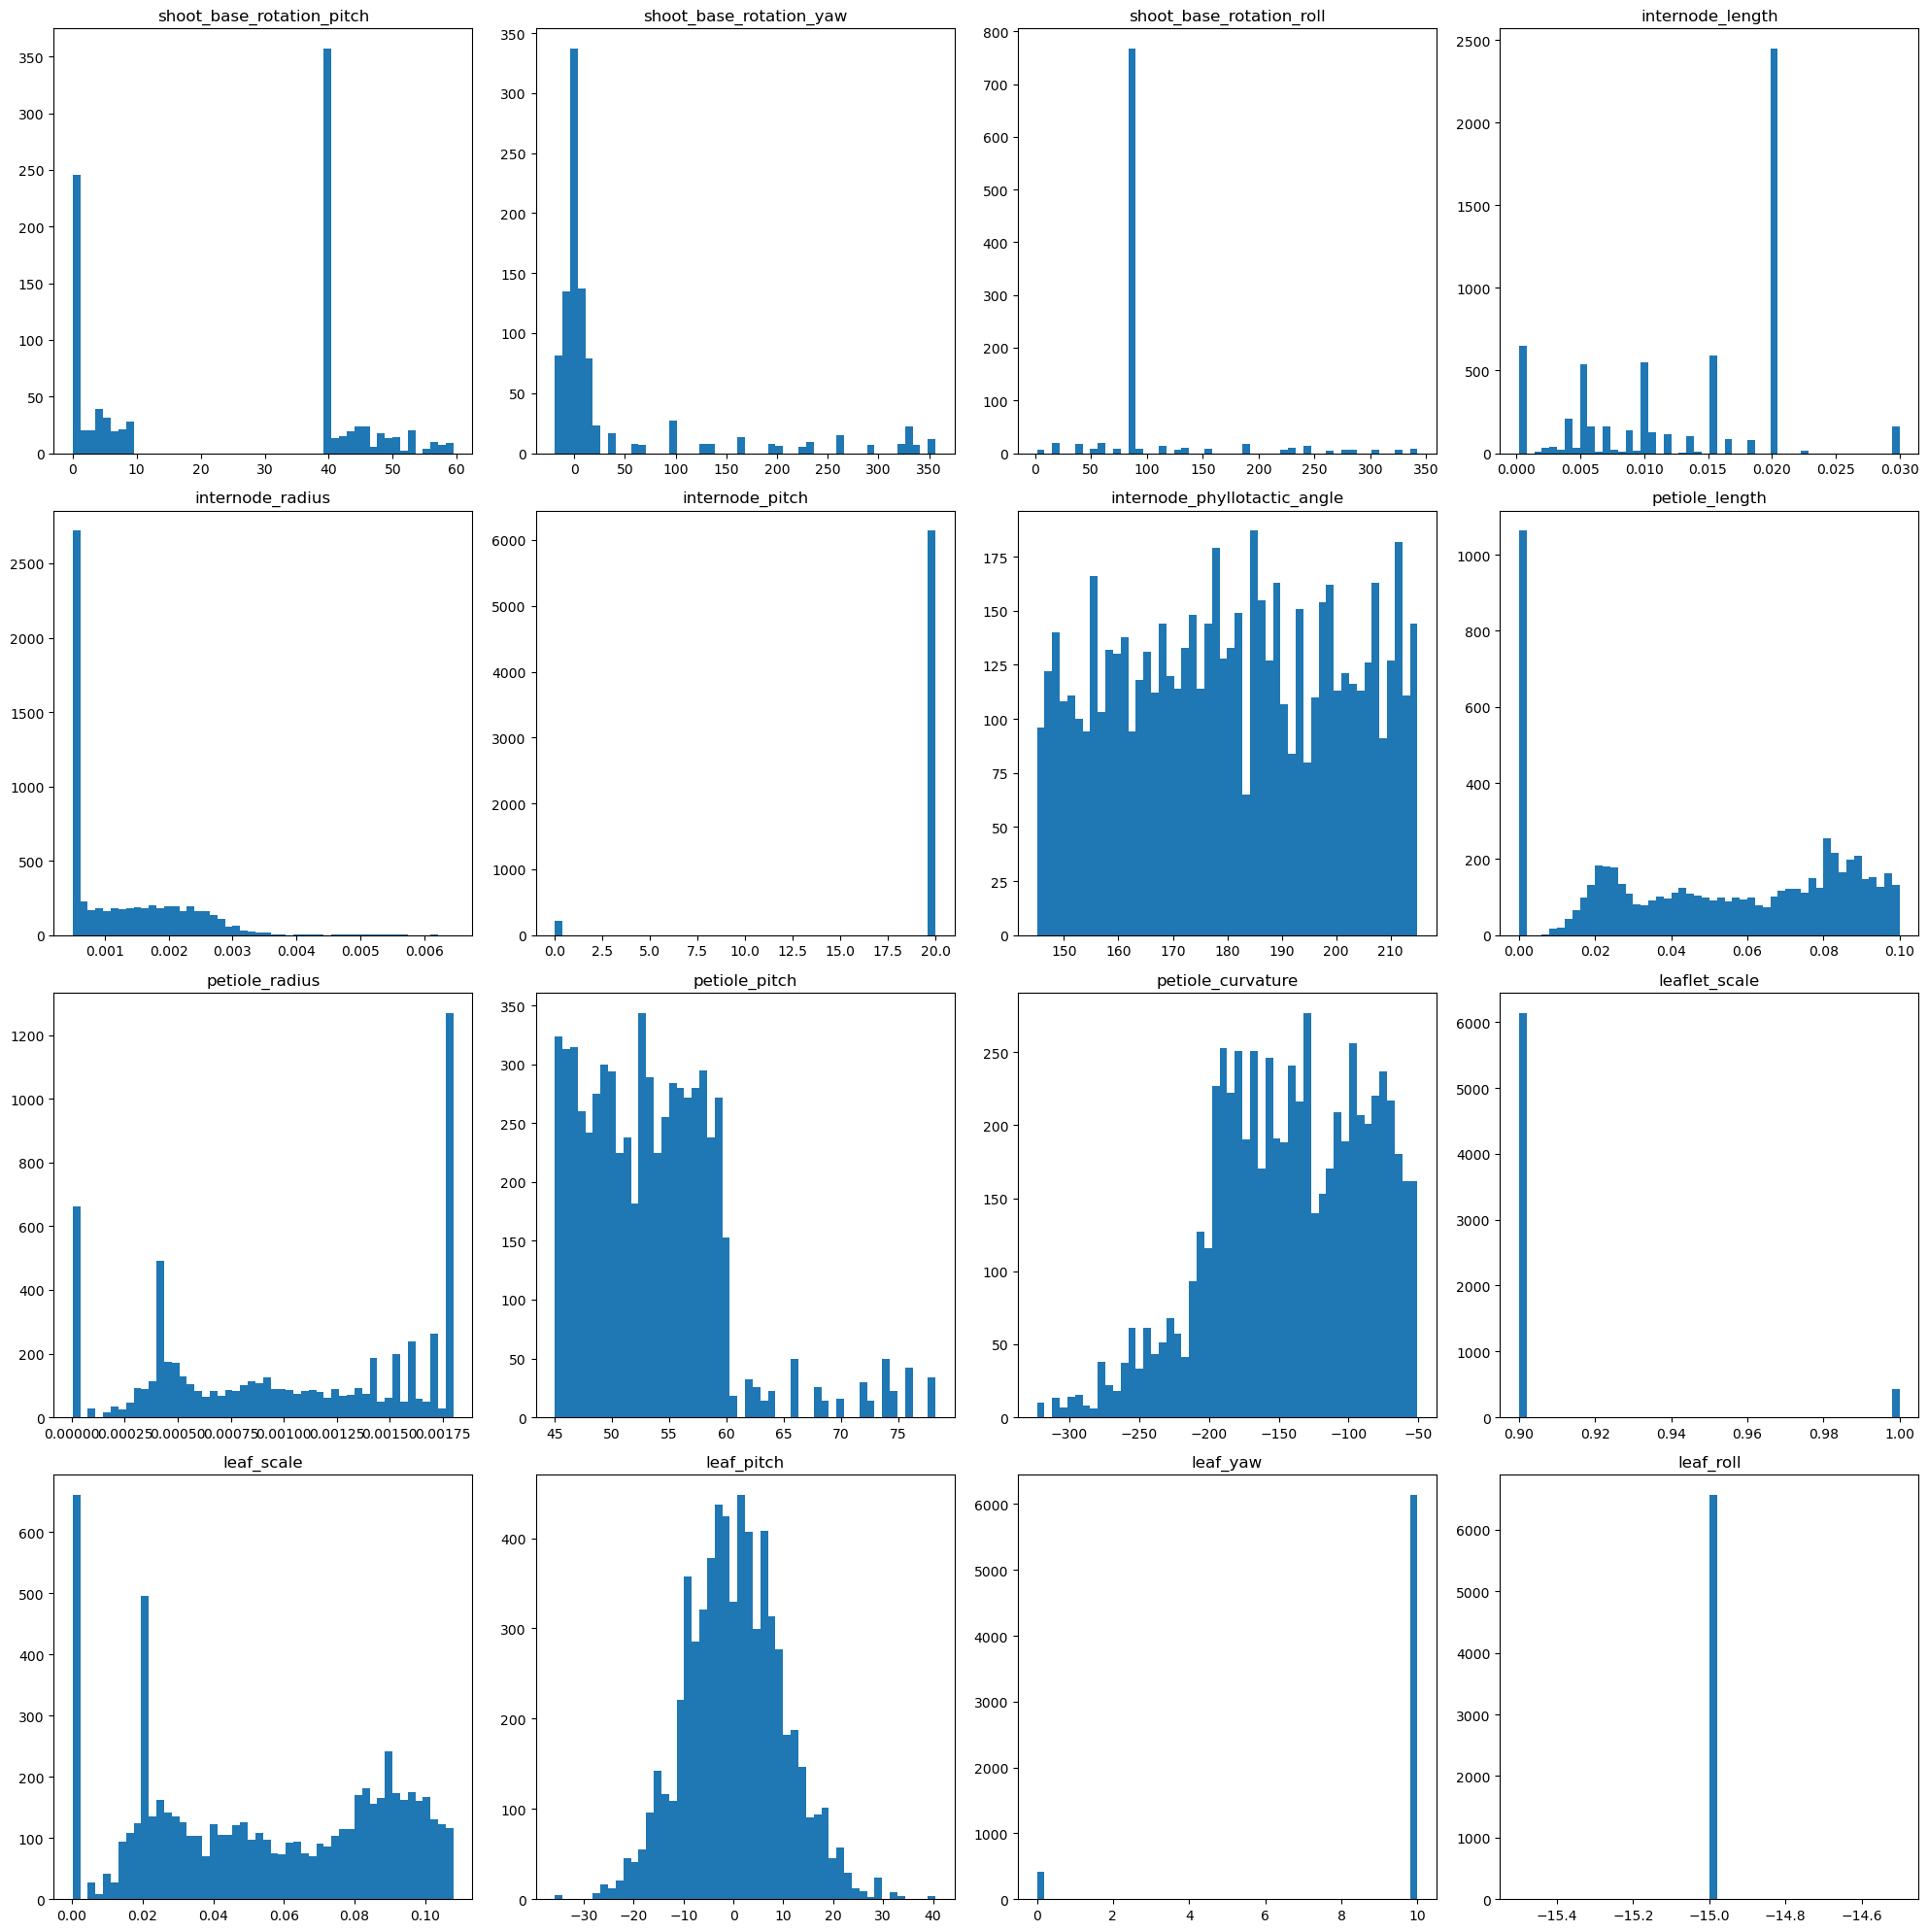

In [10]:
# Visualize the distribution of the parameters
import matplotlib.pyplot as plt

# Extract parameters
shoot_base_rotation_pitch, shoot_base_rotation_yaw, shoot_base_rotation_roll = all_shoot_params[:, 0], all_shoot_params[:, 1], all_shoot_params[:, 2]
internode_length, internode_radius, internode_pitch, internode_phyllotactic_angle = all_internode_params[:, 0], all_internode_params[:, 1], all_internode_params[:, 2], all_internode_params[:, 3]
petiole_length, petiole_radius, petiole_pitch, petiole_curvature, leaflet_scale = all_petiole_params[:, 0], all_petiole_params[:, 1], all_petiole_params[:, 2], all_petiole_params[:, 3], all_petiole_params[:, 4]
leaf_scale, leaf_pitch, leaf_yaw, leaf_roll = all_leaf_params[:, 0], all_leaf_params[:, 1], all_leaf_params[:, 2], all_leaf_params[:, 3]

params = [
    (shoot_base_rotation_pitch, "shoot_base_rotation_pitch"),
    (shoot_base_rotation_yaw, "shoot_base_rotation_yaw"),
    (shoot_base_rotation_roll, "shoot_base_rotation_roll"),
    (internode_length, "internode_length"),
    (internode_radius, "internode_radius"),
    (internode_pitch, "internode_pitch"),
    (internode_phyllotactic_angle, "internode_phyllotactic_angle"),
    (petiole_length, "petiole_length"),
    (petiole_radius, "petiole_radius"),
    (petiole_pitch, "petiole_pitch"),
    (petiole_curvature, "petiole_curvature"),
    (leaflet_scale, "leaflet_scale"),
    (leaf_scale, "leaf_scale"),
    (leaf_pitch, "leaf_pitch"),
    (leaf_yaw, "leaf_yaw"),
    (leaf_roll, "leaf_roll")
]

# Create subplots
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for ax, (param, title) in zip(axes, params):
    ax.hist(param, bins=50)
    ax.set_title(title)

# Adjust layout
plt.tight_layout()
plt.show()

Normalized shoot parameters:
 [[-0.75347639  0.1626535  -1.          0.78947368 -1.        ]
 [-1.         -0.89744165 -0.48078957 -1.          1.        ]
 [ 0.34525453 -0.82165565 -0.48078957 -1.          1.        ]
 ...
 [ 0.34525453 -0.88503115 -0.48078957 -1.          1.        ]
 [-0.77662721 -0.69697427 -0.65846059 -1.         -1.        ]
 [-1.         -0.89744165 -0.48078957 -1.          1.        ]]
Normalized internode parameters:
 [[ 1.          0.37023228 -1.          0.37686674]
 [-0.74496568 -0.29232243  1.         -0.27581965]
 [-0.63758116 -0.29476541  1.          0.47001774]
 ...
 [-0.32888533 -1.          1.         -0.3653373 ]
 [-0.99328772 -1.         -1.         -0.6324598 ]
 [-0.87919381 -1.          1.          0.99836929]]
Normalized petiole parameters:
 [[-0.99801951 -0.55902004  0.15615607  0.63009391  1.        ]
 [-0.66679136 -0.61476392 -0.47087512 -0.2872218  -1.        ]
 [-0.51228905 -0.48192984 -0.12130429 -0.33832316 -1.        ]
 ...
 [-1.         

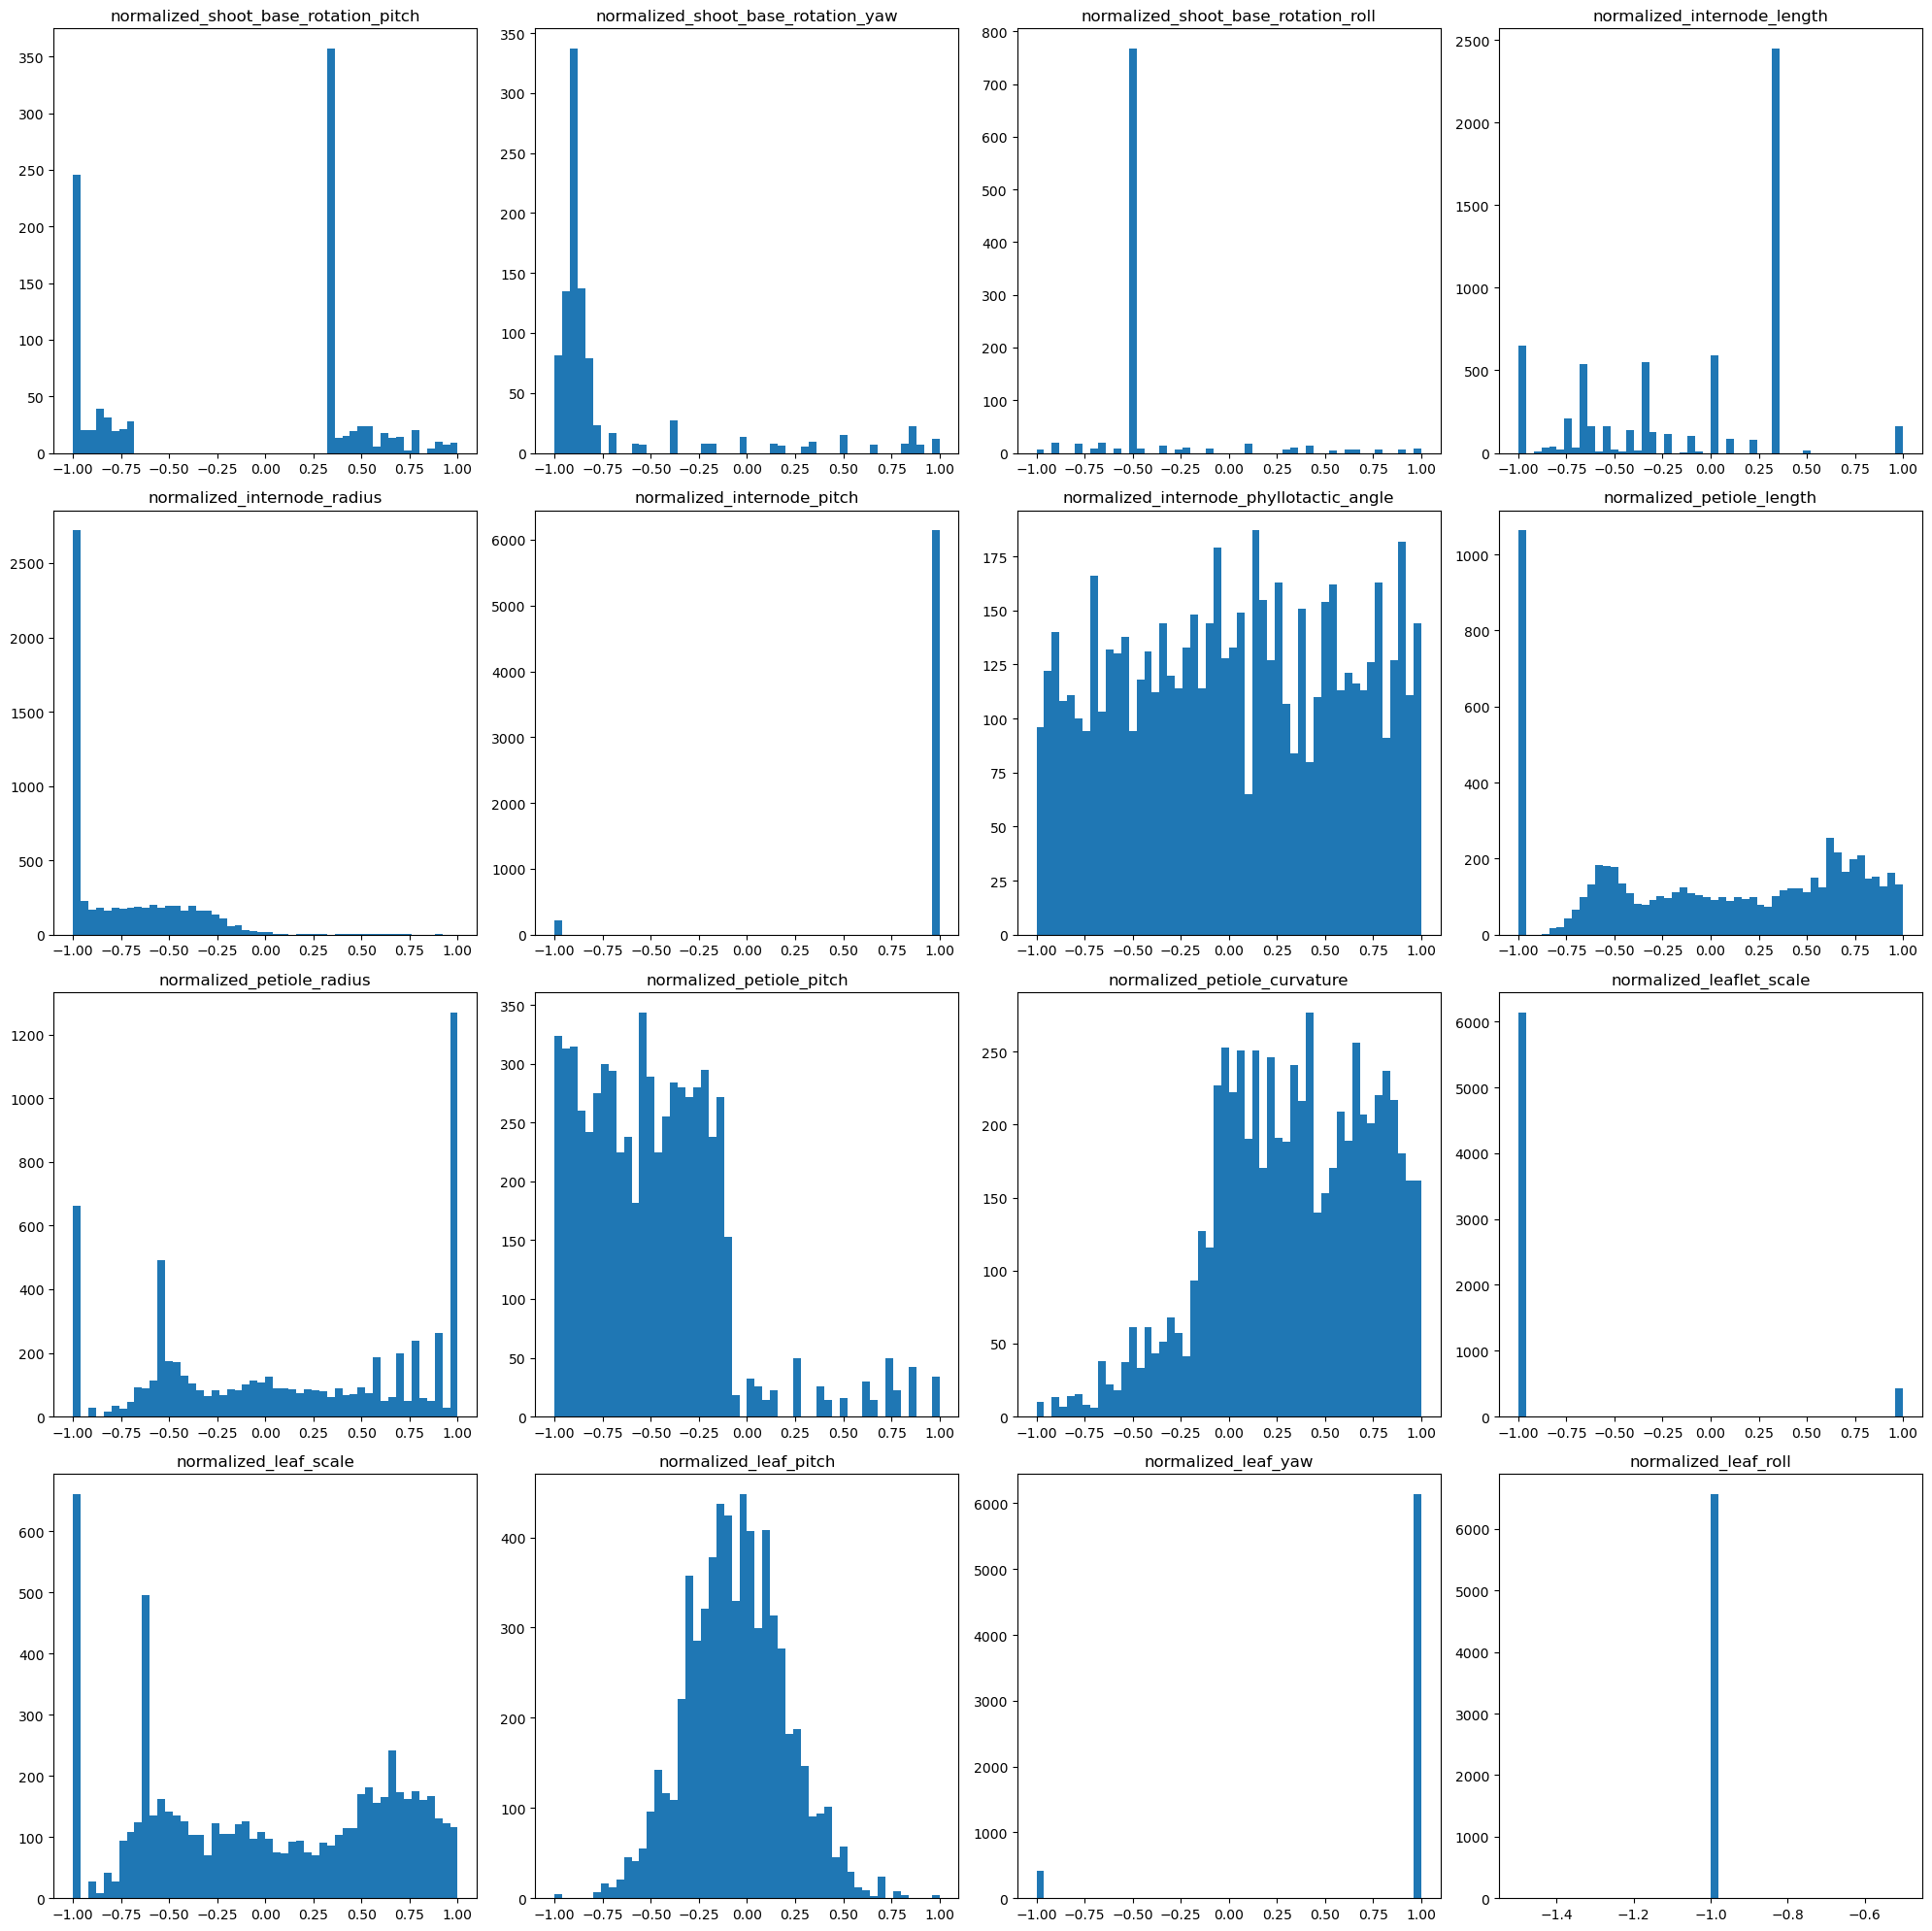

In [11]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler with feature range (-1, 1)
scaler = MinMaxScaler(feature_range=(-1, 1))

# Normalize the parameters
normalized_shoot_params = scaler.fit_transform(all_shoot_params)
normalized_internode_params = scaler.fit_transform(all_internode_params)
normalized_petiole_params = scaler.fit_transform(all_petiole_params)
normalized_leaf_params = scaler.fit_transform(all_leaf_params)

print("Normalized shoot parameters:\n", normalized_shoot_params)
print("Normalized internode parameters:\n", normalized_internode_params)
print("Normalized petiole parameters:\n", normalized_petiole_params)
print("Normalized leaf parameters:\n", normalized_leaf_params)
# Visualize the normalized parameters
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 20))
axes = axes.flatten()

normalized_params = [
    (normalized_shoot_params[:, 0], "normalized_shoot_base_rotation_pitch"),
    (normalized_shoot_params[:, 1], "normalized_shoot_base_rotation_yaw"),
    (normalized_shoot_params[:, 2], "normalized_shoot_base_rotation_roll"),
    (normalized_internode_params[:, 0], "normalized_internode_length"),
    (normalized_internode_params[:, 1], "normalized_internode_radius"),
    (normalized_internode_params[:, 2], "normalized_internode_pitch"),
    (normalized_internode_params[:, 3], "normalized_internode_phyllotactic_angle"),
    (normalized_petiole_params[:, 0], "normalized_petiole_length"),
    (normalized_petiole_params[:, 1], "normalized_petiole_radius"),
    (normalized_petiole_params[:, 2], "normalized_petiole_pitch"),
    (normalized_petiole_params[:, 3], "normalized_petiole_curvature"),
    (normalized_petiole_params[:, 4], "normalized_leaflet_scale"),
    (normalized_leaf_params[:, 0], "normalized_leaf_scale"),
    (normalized_leaf_params[:, 1], "normalized_leaf_pitch"),
    (normalized_leaf_params[:, 2], "normalized_leaf_yaw"),
    (normalized_leaf_params[:, 3], "normalized_leaf_roll")
]

for ax, (param, title) in zip(axes, normalized_params):
    ax.hist(param, bins=50)
    ax.set_title(title)

# Adjust layout
plt.tight_layout()
plt.show()

In [12]:
from plant_tokenizer import token2vec, vec2token
# Convert plant array to plant tokens
total_tokens = None
for array_line in plant_array:
    token = vec2token(array_line)
    token = np.array(token) 
    if total_tokens is None:
        total_tokens = token
    else:
        total_tokens = np.concatenate([total_tokens, token])


ModuleNotFoundError: No module named 'src.plant_architecture_utils'

# Tokenizer Scale

In [8]:
# Scale tokens except for depth-organ
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler with feature range (-1, 1)
scaler = MinMaxScaler(feature_range=(-1, 1))

# Normalize the parameters
scaled_params = scaler.fit_transform(total_tokens[:,1:])
total_tokens_scaled = np.concatenate([total_tokens[:,:1],scaled_params],axis=1)

print(total_tokens_scaled)

[[ 0.         -0.80330637 -0.72062659 ... -0.02722045  0.
   1.        ]
 [ 1.         -1.         -0.89696211 ... -0.02722045  0.
   1.        ]
 [ 2.         -1.         -0.89696211 ... -0.02722045  0.
   1.        ]
 ...
 [ 9.         -1.         -0.89696211 ... -0.05707073  1.
  -1.        ]
 [10.         -1.         -0.89696211 ...  0.10414859  0.
  -1.        ]
 [11.         -1.         -0.89696211 ... -0.20357104 -1.
  -1.        ]]


(8827, 5)
(58572, 4)
(60572, 5)
(60572, 4)


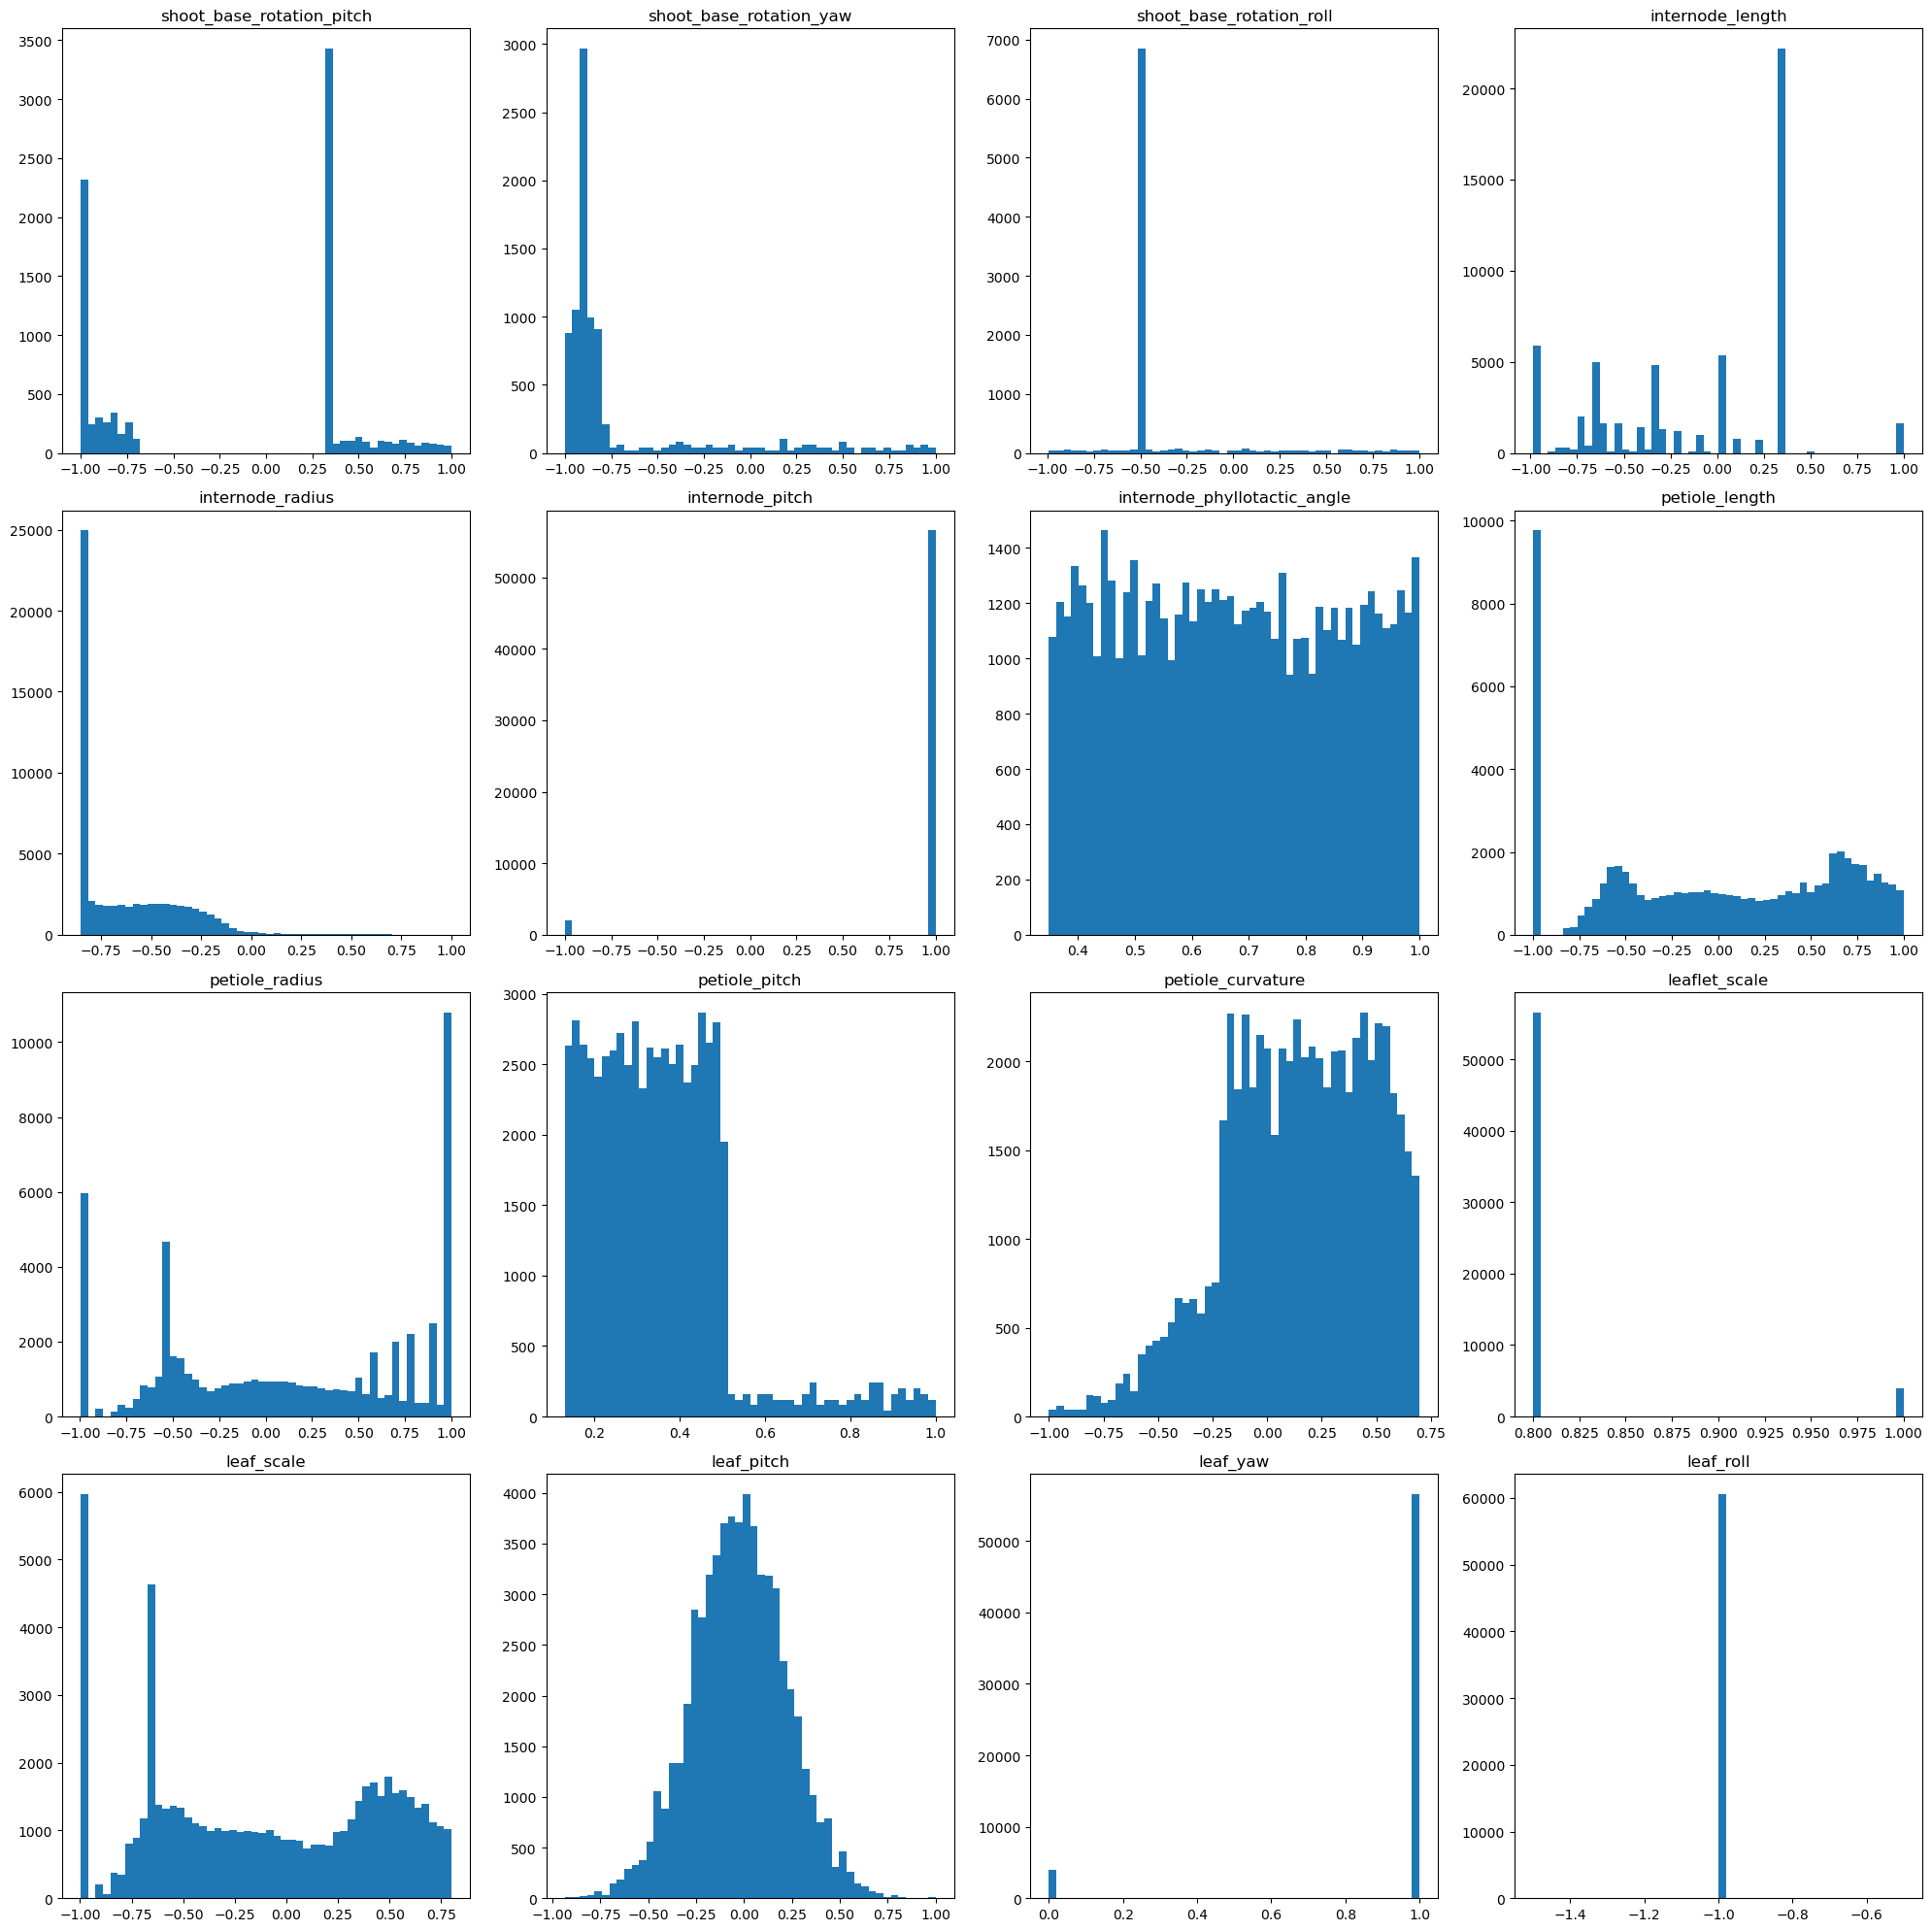

In [9]:
# from plant_tokenizer import unscale_vec, scale_vec
# The parameter will be quantized by organ types
all_shoot_params = []
all_internode_params = []
all_petiole_params = []
all_leaf_params = []
all_params_numbers = []
for token in total_tokens_scaled:
    # plant_vectors = scale_vec(plant_vectors)
    depth = token[0] // 6
    organ_type = token[0] % 6
    if organ_type == 0:
        all_shoot_params.append(token[1:6])
    elif organ_type == 1:
        all_internode_params.append(token[6:10])
    elif organ_type == 2:
        all_petiole_params.append(token[10:15])
    elif organ_type == 3:
        all_leaf_params.append(token[15:19])

all_shoot_params = np.array(all_shoot_params)
all_internode_params = np.array(all_internode_params)
all_petiole_params = np.array(all_petiole_params)
all_leaf_params = np.array(all_leaf_params)

print(all_shoot_params.shape)
print(all_internode_params.shape)
print(all_petiole_params.shape)
print(all_leaf_params.shape)


# Visualize the distribution of the parameters
import matplotlib.pyplot as plt

# Extract parameters
shoot_base_rotation_pitch, shoot_base_rotation_yaw, shoot_base_rotation_roll = all_shoot_params[:, 0], all_shoot_params[:, 1], all_shoot_params[:, 2]
internode_length, internode_radius, internode_pitch, internode_phyllotactic_angle = all_internode_params[:, 0], all_internode_params[:, 1], all_internode_params[:, 2], all_internode_params[:, 3]
petiole_length, petiole_radius, petiole_pitch, petiole_curvature, leaflet_scale = all_petiole_params[:, 0], all_petiole_params[:, 1], all_petiole_params[:, 2], all_petiole_params[:, 3], all_petiole_params[:, 4]
leaf_scale, leaf_pitch, leaf_yaw, leaf_roll = all_leaf_params[:, 0], all_leaf_params[:, 1], all_leaf_params[:, 2], all_leaf_params[:, 3]

params = [
    (shoot_base_rotation_pitch, "shoot_base_rotation_pitch"),
    (shoot_base_rotation_yaw, "shoot_base_rotation_yaw"),
    (shoot_base_rotation_roll, "shoot_base_rotation_roll"),
    (internode_length, "internode_length"),
    (internode_radius, "internode_radius"),
    (internode_pitch, "internode_pitch"),
    (internode_phyllotactic_angle, "internode_phyllotactic_angle"),
    (petiole_length, "petiole_length"),
    (petiole_radius, "petiole_radius"),
    (petiole_pitch, "petiole_pitch"),
    (petiole_curvature, "petiole_curvature"),
    (leaflet_scale, "leaflet_scale"),
    (leaf_scale, "leaf_scale"),
    (leaf_pitch, "leaf_pitch"),
    (leaf_yaw, "leaf_yaw"),
    (leaf_roll, "leaf_roll")
]

# Create subplots
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for ax, (param, title) in zip(axes, params):
    ax.hist(param, bins=50)
    ax.set_title(title)

# Adjust layout
plt.tight_layout()
plt.show()

In [10]:
# Test inverse scale

# Normalize the parameters
scaled_params = scaler.inverse_transform(total_tokens_scaled[:,1:])
total_tokens_recovered = np.concatenate([total_tokens[:,:1],scaled_params],axis=1)

print(total_tokens_recovered)


[[  0.        5.88527  33.1074  ...   0.        0.        0.     ]
 [  1.        0.        0.      ...   0.        0.        0.     ]
 [  2.        0.        0.      ...   0.        0.        0.     ]
 ...
 [  9.        0.        0.      ...  -1.17661  10.      -15.     ]
 [ 10.        0.        0.      ...   5.17818   0.      -15.     ]
 [ 11.        0.        0.      ...  -6.95122 -10.      -15.     ]]


(8827, 5)
(58572, 4)
(60572, 5)
(60572, 4)


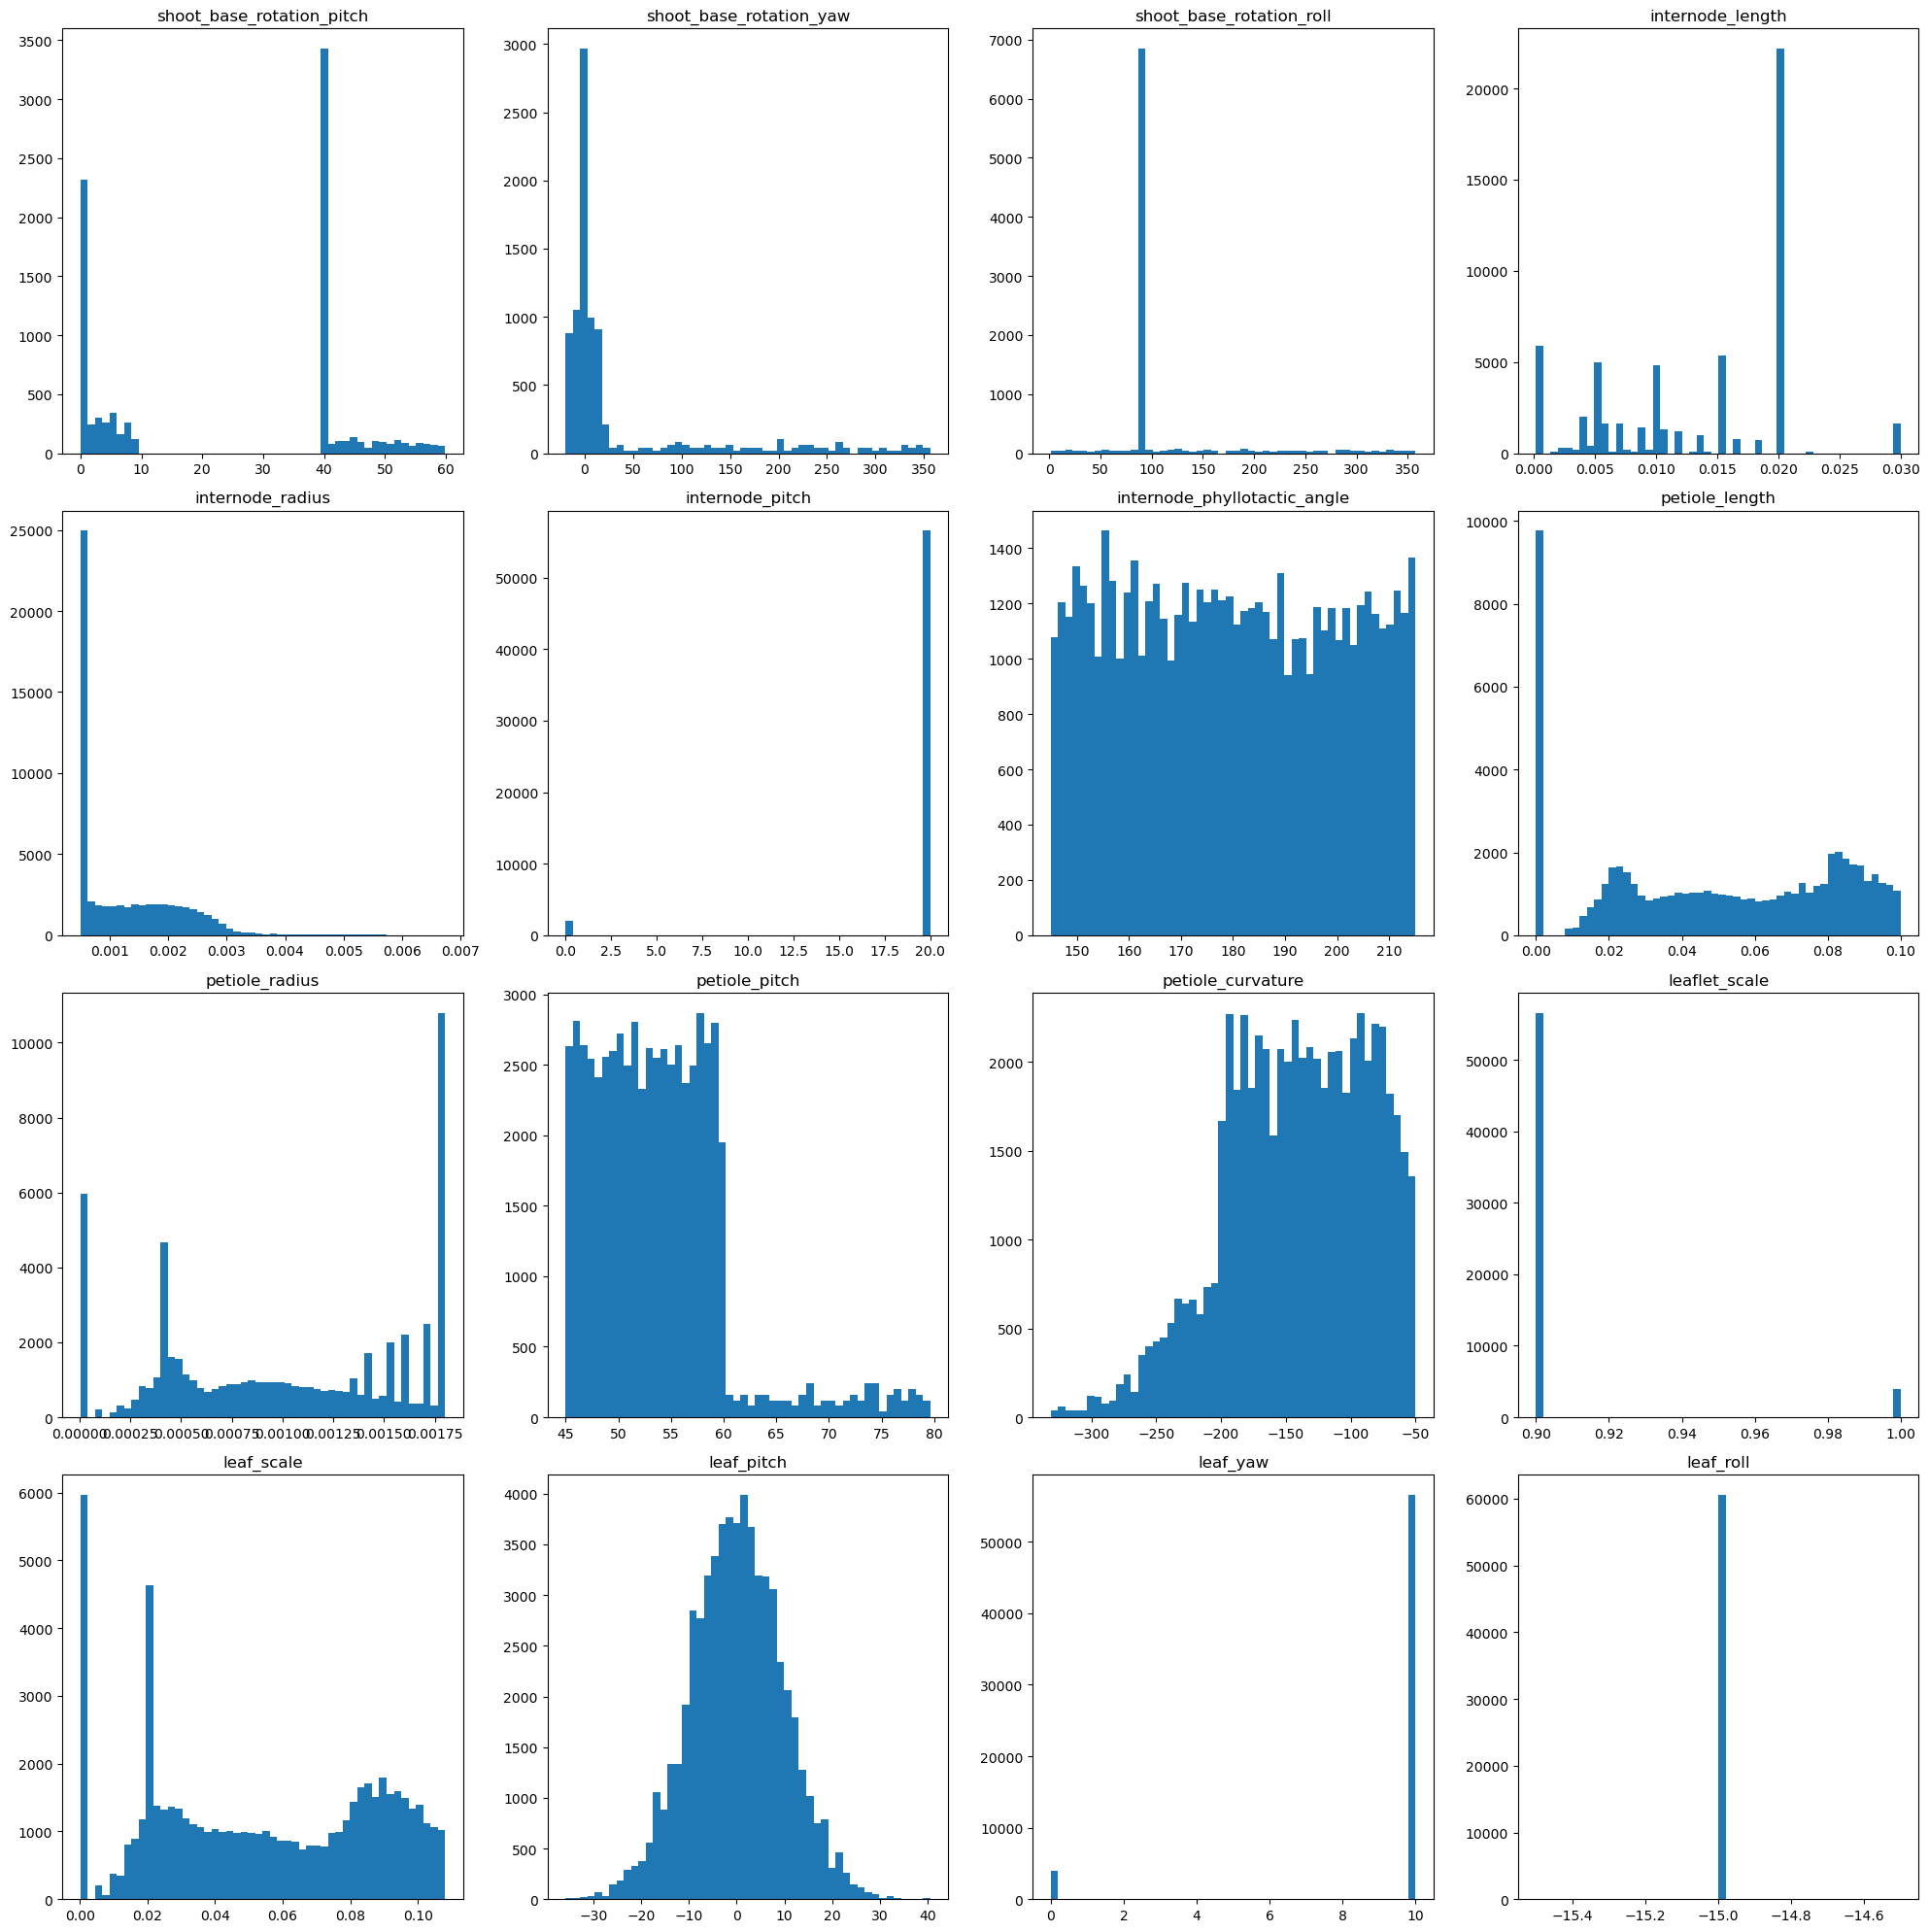

In [11]:
# from plant_tokenizer import unscale_vec, scale_vec
# The parameter will be quantized by organ types
all_shoot_params = []
all_internode_params = []
all_petiole_params = []
all_leaf_params = []
all_params_numbers = []
for token in total_tokens_recovered:
    # plant_vectors = scale_vec(plant_vectors)
    depth = token[0] // 6
    organ_type = token[0] % 6
    if organ_type == 0:
        all_shoot_params.append(token[1:6])
    elif organ_type == 1:
        all_internode_params.append(token[6:10])
    elif organ_type == 2:
        all_petiole_params.append(token[10:15])
    elif organ_type == 3:
        all_leaf_params.append(token[15:19])

all_shoot_params = np.array(all_shoot_params)
all_internode_params = np.array(all_internode_params)
all_petiole_params = np.array(all_petiole_params)
all_leaf_params = np.array(all_leaf_params)

print(all_shoot_params.shape)
print(all_internode_params.shape)
print(all_petiole_params.shape)
print(all_leaf_params.shape)


# Visualize the distribution of the parameters
import matplotlib.pyplot as plt

# Extract parameters
shoot_base_rotation_pitch, shoot_base_rotation_yaw, shoot_base_rotation_roll = all_shoot_params[:, 0], all_shoot_params[:, 1], all_shoot_params[:, 2]
internode_length, internode_radius, internode_pitch, internode_phyllotactic_angle = all_internode_params[:, 0], all_internode_params[:, 1], all_internode_params[:, 2], all_internode_params[:, 3]
petiole_length, petiole_radius, petiole_pitch, petiole_curvature, leaflet_scale = all_petiole_params[:, 0], all_petiole_params[:, 1], all_petiole_params[:, 2], all_petiole_params[:, 3], all_petiole_params[:, 4]
leaf_scale, leaf_pitch, leaf_yaw, leaf_roll = all_leaf_params[:, 0], all_leaf_params[:, 1], all_leaf_params[:, 2], all_leaf_params[:, 3]

params = [
    (shoot_base_rotation_pitch, "shoot_base_rotation_pitch"),
    (shoot_base_rotation_yaw, "shoot_base_rotation_yaw"),
    (shoot_base_rotation_roll, "shoot_base_rotation_roll"),
    (internode_length, "internode_length"),
    (internode_radius, "internode_radius"),
    (internode_pitch, "internode_pitch"),
    (internode_phyllotactic_angle, "internode_phyllotactic_angle"),
    (petiole_length, "petiole_length"),
    (petiole_radius, "petiole_radius"),
    (petiole_pitch, "petiole_pitch"),
    (petiole_curvature, "petiole_curvature"),
    (leaflet_scale, "leaflet_scale"),
    (leaf_scale, "leaf_scale"),
    (leaf_pitch, "leaf_pitch"),
    (leaf_yaw, "leaf_yaw"),
    (leaf_roll, "leaf_roll")
]

# Create subplots
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for ax, (param, title) in zip(axes, params):
    ax.hist(param, bins=50)
    ax.set_title(title)

# Adjust layout
plt.tight_layout()
plt.show()

In [12]:
import joblib
# Save scaler to file
# Save the scaler to a file
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [13]:
# 스케일러 요약 정보 출력
def print_scaler_summary(scaler):
    print("MinMaxScaler Summary:")
    print(f"Data Min: {scaler.data_min_}")
    print(f"Data Max: {scaler.data_max_}")
    print(f"Scale: {scaler.scale_}")
    print(f"Min: {scaler.min_}")

print_scaler_summary(scaler)

MinMaxScaler Summary:
Data Min: [   0.      -19.3456    0.        0.        0.        0.        0.
    0.        0.        0.        0.        0.     -331.326     0.
    0.      -38.3441  -10.      -15.    ]
Data Max: [5.98420e+01 3.56159e+02 3.57383e+02 1.90000e+01 3.00000e+00 3.00000e-02
 6.73295e-03 2.00000e+01 2.15000e+02 9.99985e-02 1.80000e-03 7.95954e+01
 0.00000e+00 1.00000e+00 1.20000e-01 4.04900e+01 1.00000e+01 0.00000e+00]
Scale: [3.34213429e-02 5.32616644e-03 5.59623709e-03 1.05263158e-01
 6.66666667e-01 6.66666667e+01 2.97046614e+02 1.00000000e-01
 9.30232558e-03 2.00003000e+01 1.11111111e+03 2.51270802e-02
 6.03635091e-03 2.00000000e+00 1.66666667e+01 2.53697321e-02
 1.00000000e-01 1.33333333e-01]
Min: [-1.         -0.89696211 -1.         -1.         -1.         -1.
 -1.         -1.         -1.         -1.         -1.         -1.
  1.         -1.         -1.         -0.02722045  0.          1.        ]


In [32]:
import torch
import torch.nn as nn

class MinMaxScalerTorch(nn.Module):
    def __init__(self, feature_range=(-1, 1)):
        super(MinMaxScalerTorch, self).__init__()
        self.min, self.max = feature_range
        self.data_min_ = torch.tensor([0, -19.3456, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -331.326, 0, 0, -38.3441, -10, -15], dtype=torch.float32, requires_grad=False)
        self.data_max_ = torch.tensor([59.842, 356.159, 357.383, 19, 3, 0.03, 0.00673295, 20, 215, 0.0999985, 0.0018, 79.5954, 0, 1, 0.12, 40.49, 10, 0], dtype=torch.float32, requires_grad=False)
        self.scale_ = torch.tensor([3.34213429e-02, 5.32616644e-03, 5.59623709e-03, 1.05263158e-01,
                                    6.66666667e-01, 6.66666667e+01, 2.97046614e+02, 1.00000000e-01,
                                    9.30232558e-03, 2.00003000e+01, 1.11111111e+03, 2.51270802e-02,
                                    6.03635091e-03, 2.00000000e+00, 1.66666667e+01, 2.53697321e-02,
                                    1.00000000e-01, 1.33333333e-01], dtype=torch.float32, requires_grad=False)
        self.min_ = torch.tensor([-1., -0.89696211, -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
                                  1., -1., -1., -0.02722045, 0., 1.], dtype=torch.float32, requires_grad=False)

        # 1D Convolution layer for scaling and inverse scaling
        self.conv = nn.Conv1d(in_channels=18, out_channels=18, kernel_size=1, bias=True)
        self.inv_conv = nn.Conv1d(in_channels=18, out_channels=18, kernel_size=1, bias=True)

        # Initialize convolution weights and bias
        self.conv.weight.data = torch.diag(self.scale_).view(18, 18, 1)
        self.conv.bias.data = self.min_

        # Initialize inverse convolution weights and bias
        self.inv_conv.weight.data = torch.diag(1/self.scale_).view(18, 18, 1)
        self.inv_conv.bias.data = -self.min_ / self.scale_

    def fit(self, data):
        self.data_min_ = data.min(0, keepdim=True)[0]
        self.data_max_ = data.max(0, keepdim=True)[0]
        self.scale_ = (self.max - self.min) / (self.data_max_ - self.data_min_)
        self.min_ = self.min - self.data_min_ * self.scale_

        # Update convolution weights and bias
        self.conv.weight.data = torch.diag(self.scale_).view(18, 18, 1)
        self.conv.bias.data = self.min_

        # Update inverse convolution weights and bias
        self.inv_conv.weight.data = (1 / self.scale_).view(1, 18, 1)
        self.inv_conv.bias.data = -self.min_ / self.scale_

    def transform(self, data):
        with torch.no_grad():
            data = data.permute(0, 2, 1)  # (batch_size, seq_len, num_features) -> (batch_size, num_features, seq_len)
            transformed = self.conv(data)
        return transformed.permute(0, 2, 1)  # (batch_size, num_features, seq_len) -> (batch_size, seq_len, num_features)

    def inverse_transform(self, data):
        with torch.no_grad():
            data = data.permute(0, 2, 1)  # (batch_size, seq_len, num_features) -> (batch_size, num_features, seq_len)
            inverse_transformed = self.inv_conv(data)
        return inverse_transformed.permute(0, 2, 1)  # (batch_size, num_features, seq_len) -> (batch_size, seq_len, num_features)

In [33]:
# Test inverse scale
scaler = MinMaxScalerTorch()
# Normalize the parameters
total_tokens_scaled_tensor = torch.tensor(total_tokens_scaled[:,1:],dtype=torch.float).view(-1,1,18)
scaled_params_tensor = scaler.inverse_transform(total_tokens_scaled_tensor)
scaled_params = scaled_params_tensor.numpy().squeeze()
total_tokens_recovered = np.concatenate([total_tokens[:,:1],scaled_params],axis=1)

print(total_tokens_recovered)


[[ 0.00000000e+00  5.88526917e+00  3.31074066e+01 ... -1.19209290e-07
   0.00000000e+00  0.00000000e+00]
 [ 1.00000000e+00  0.00000000e+00  0.00000000e+00 ... -1.19209290e-07
   0.00000000e+00  0.00000000e+00]
 [ 2.00000000e+00  0.00000000e+00  0.00000000e+00 ... -1.19209290e-07
   0.00000000e+00  0.00000000e+00]
 ...
 [ 9.00000000e+00  0.00000000e+00  0.00000000e+00 ... -1.17661023e+00
   1.00000000e+01 -1.49999990e+01]
 [ 1.00000000e+01  0.00000000e+00  0.00000000e+00 ...  5.17817974e+00
   0.00000000e+00 -1.49999990e+01]
 [ 1.10000000e+01  0.00000000e+00  0.00000000e+00 ... -6.95122004e+00
  -1.00000000e+01 -1.49999990e+01]]


(8827, 5)
(58572, 4)
(60572, 5)
(60572, 4)


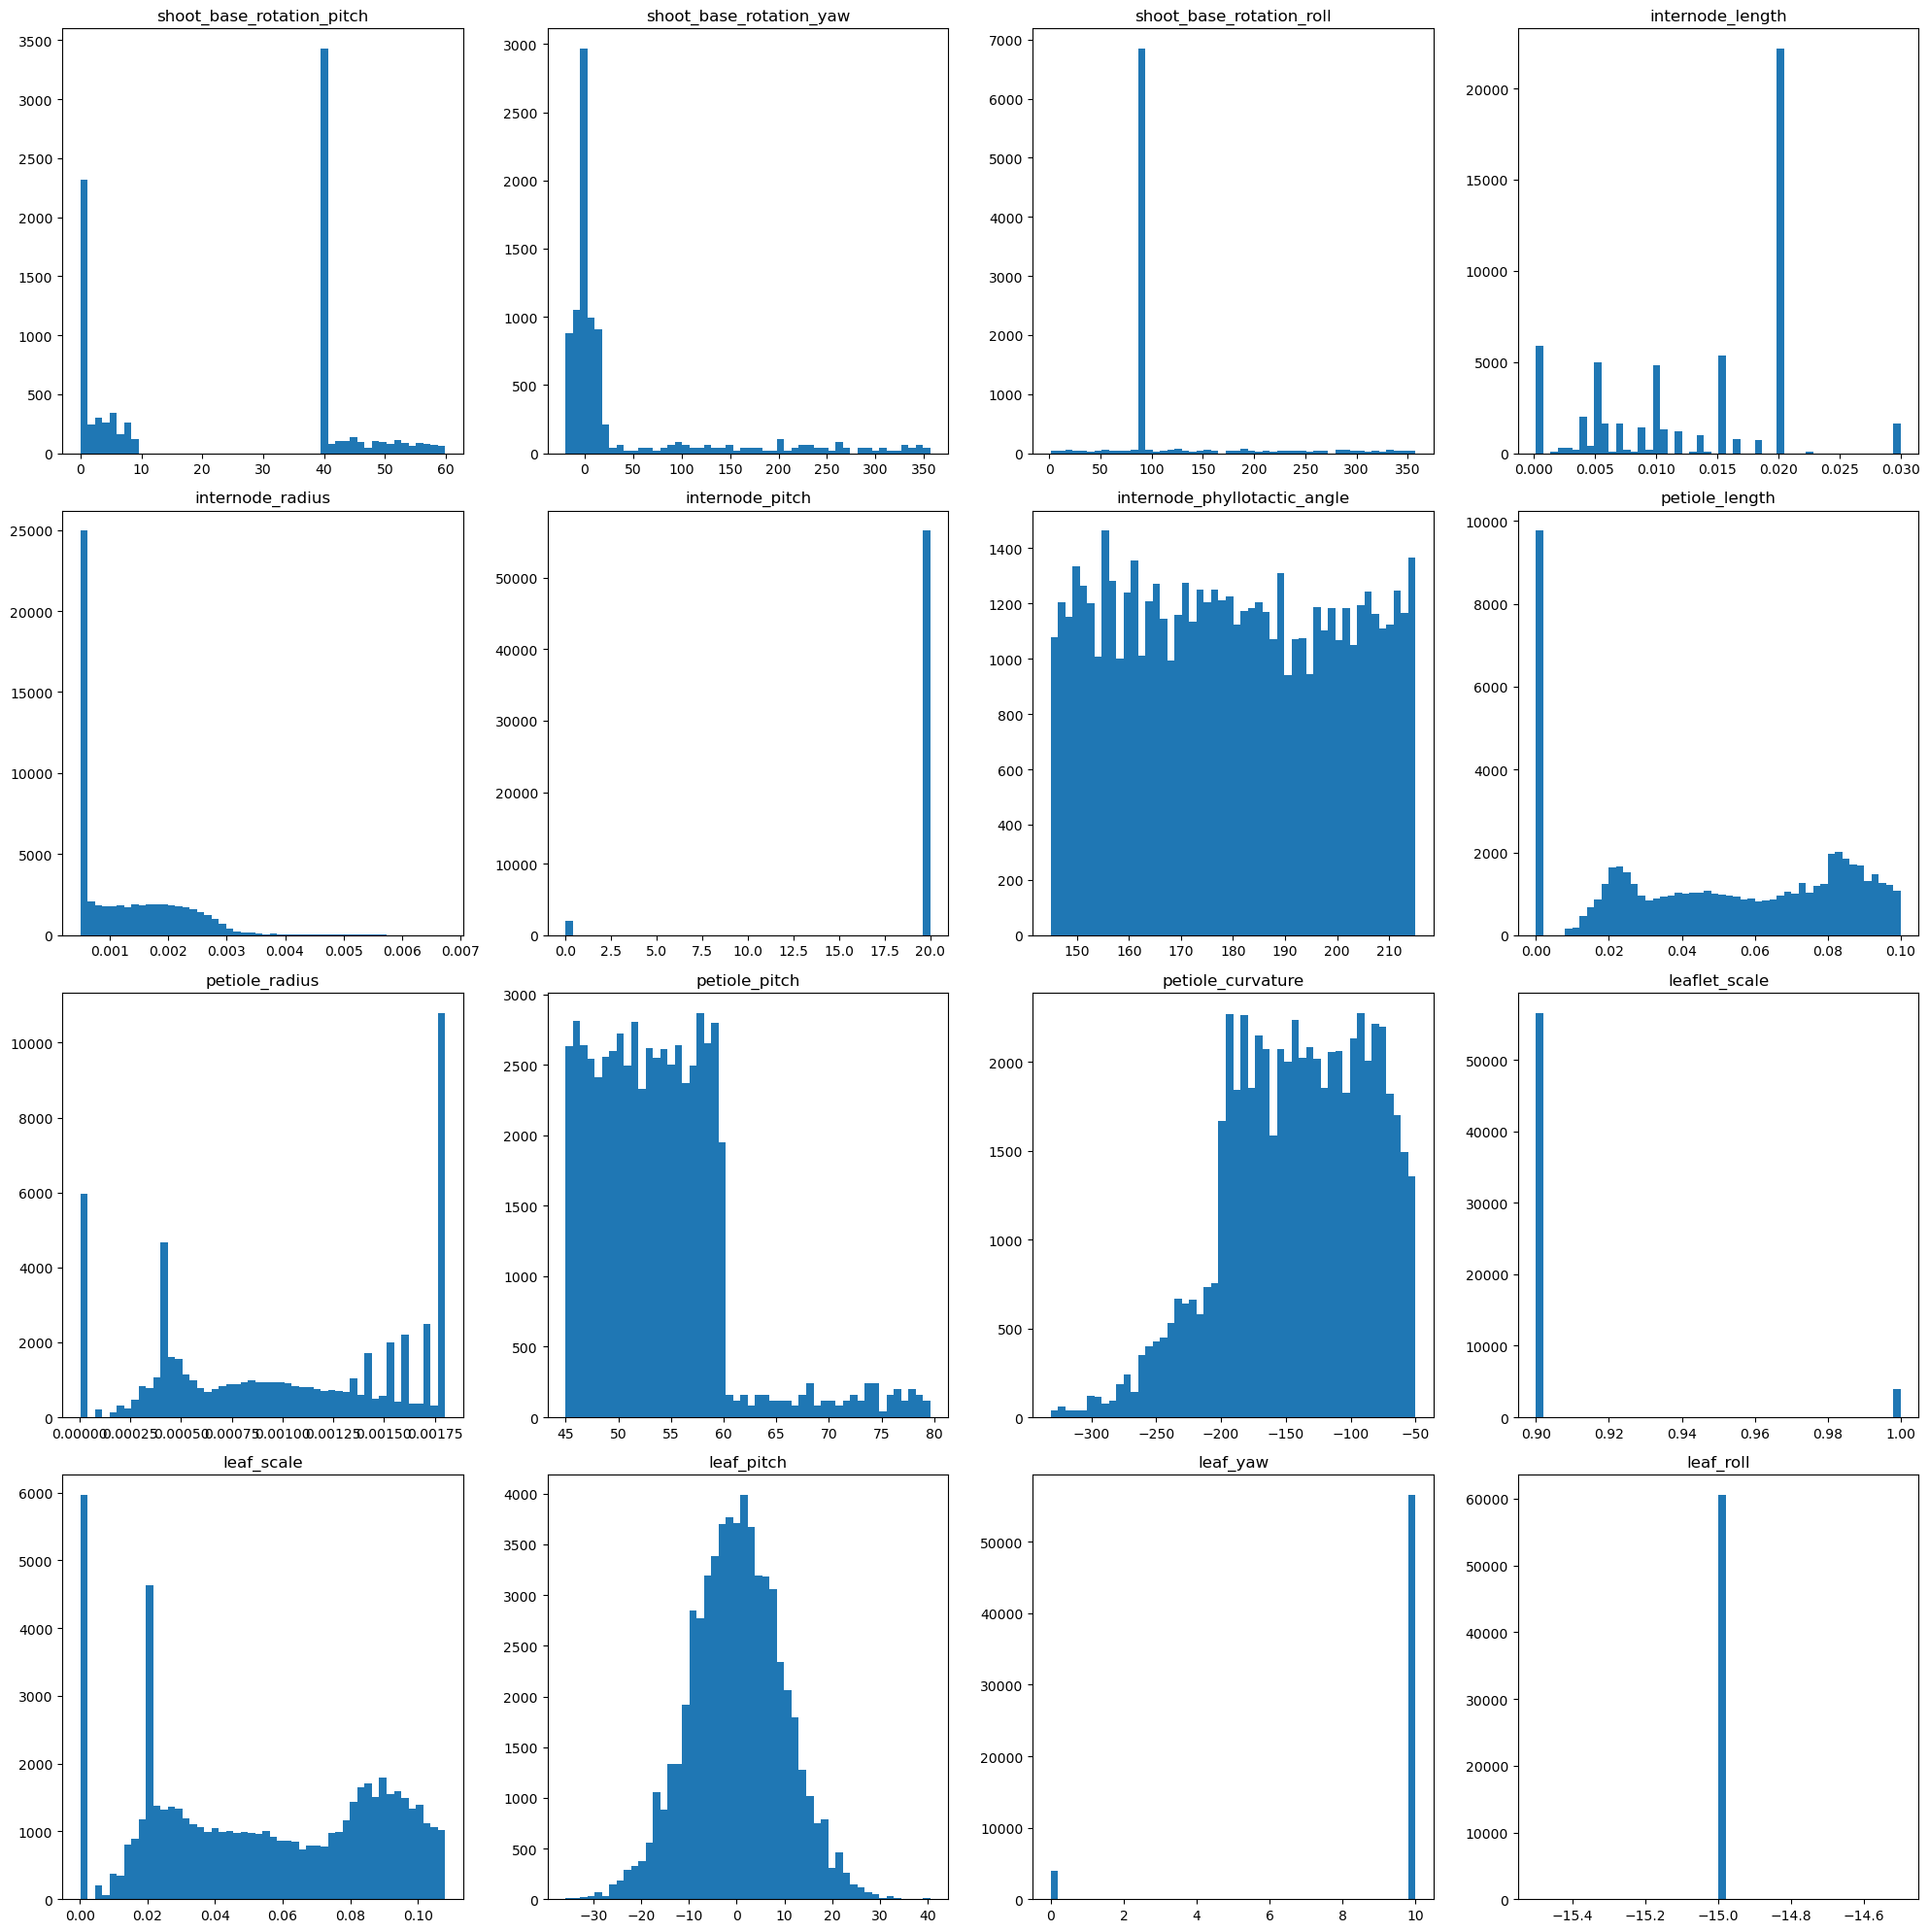

In [34]:
# from plant_tokenizer import unscale_vec, scale_vec
# The parameter will be quantized by organ types
all_shoot_params = []
all_internode_params = []
all_petiole_params = []
all_leaf_params = []
all_params_numbers = []
for token in total_tokens_recovered:
    # plant_vectors = scale_vec(plant_vectors)
    depth = token[0] // 6
    organ_type = token[0] % 6
    if organ_type == 0:
        all_shoot_params.append(token[1:6])
    elif organ_type == 1:
        all_internode_params.append(token[6:10])
    elif organ_type == 2:
        all_petiole_params.append(token[10:15])
    elif organ_type == 3:
        all_leaf_params.append(token[15:19])

all_shoot_params = np.array(all_shoot_params)
all_internode_params = np.array(all_internode_params)
all_petiole_params = np.array(all_petiole_params)
all_leaf_params = np.array(all_leaf_params)

print(all_shoot_params.shape)
print(all_internode_params.shape)
print(all_petiole_params.shape)
print(all_leaf_params.shape)


# Visualize the distribution of the parameters
import matplotlib.pyplot as plt

# Extract parameters
shoot_base_rotation_pitch, shoot_base_rotation_yaw, shoot_base_rotation_roll = all_shoot_params[:, 0], all_shoot_params[:, 1], all_shoot_params[:, 2]
internode_length, internode_radius, internode_pitch, internode_phyllotactic_angle = all_internode_params[:, 0], all_internode_params[:, 1], all_internode_params[:, 2], all_internode_params[:, 3]
petiole_length, petiole_radius, petiole_pitch, petiole_curvature, leaflet_scale = all_petiole_params[:, 0], all_petiole_params[:, 1], all_petiole_params[:, 2], all_petiole_params[:, 3], all_petiole_params[:, 4]
leaf_scale, leaf_pitch, leaf_yaw, leaf_roll = all_leaf_params[:, 0], all_leaf_params[:, 1], all_leaf_params[:, 2], all_leaf_params[:, 3]

params = [
    (shoot_base_rotation_pitch, "shoot_base_rotation_pitch"),
    (shoot_base_rotation_yaw, "shoot_base_rotation_yaw"),
    (shoot_base_rotation_roll, "shoot_base_rotation_roll"),
    (internode_length, "internode_length"),
    (internode_radius, "internode_radius"),
    (internode_pitch, "internode_pitch"),
    (internode_phyllotactic_angle, "internode_phyllotactic_angle"),
    (petiole_length, "petiole_length"),
    (petiole_radius, "petiole_radius"),
    (petiole_pitch, "petiole_pitch"),
    (petiole_curvature, "petiole_curvature"),
    (leaflet_scale, "leaflet_scale"),
    (leaf_scale, "leaf_scale"),
    (leaf_pitch, "leaf_pitch"),
    (leaf_yaw, "leaf_yaw"),
    (leaf_roll, "leaf_roll")
]

# Create subplots
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for ax, (param, title) in zip(axes, params):
    ax.hist(param, bins=50)
    ax.set_title(title)

# Adjust layout
plt.tight_layout()
plt.show()